In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import json
from multiprocessing import cpu_count
from scipy.sparse.linalg import eigs

# プロジェクトルートをパスに追加
current_dir = os.path.dirname(os.path.abspath('.'))
sys.path.append(current_dir)
sys.path.append(os.path.abspath(os.path.join(current_dir, "..")))

from simulation.network import Network, ER

# グラフ全体のフォント設定
plt.rcParams['font.family'] = 'serif'  # 全体のフォントをSerifに設定
plt.rcParams['mathtext.fontset'] = 'cm'  # 数式のフォントをComputer Modernに設定
plt.rcParams['mathtext.rm'] = 'serif'  # TeXの通常フォントをSerifに設定
plt.rcParams['font.size'] = 18  # デフォルトフォントサイズ
plt.rcParams['axes.labelsize'] = 18  # 軸ラベルのフォントサイズ
plt.rcParams['axes.titlesize'] = 22  # タイトルのフォントサイズ
plt.rcParams['legend.fontsize'] = 16  # 凡例のフォントサイズ
plt.rcParams['grid.color'] = 'gray'  # グリッドの色を薄い灰色に設定
plt.rcParams['grid.linestyle'] = ':'  # グリッドを点線に設定
plt.rcParams['grid.linewidth'] = 0.5  # グリッドの線幅を設定

In [41]:
import numpy as np
from scipy.sparse.linalg import eigs

N = 1000
k_ave = 10

r_high = 1.0
q = 0.02

g = ER(N, k_ave / (N - 1))

A = np.zeros((N, N), dtype=float)
for i in range(N):
    for jidx in range(g.address_list[i], g.cursor_list[i]):
        j = g.edge_list[jidx]
        if i < j:
            A[i, j] = 1
            A[j, i] = 1

# 最大の固有値（絶対値が最大のものを1つ取得）
eigvals, eigvecs = eigs(A, k=1, which='LM')

print("最大固有値:", eigvals[0].real)
iterations = 10
eigvals = np.zeros(iterations)
eigvecs = np.zeros((iterations, N))

early_num = int(N * q)

# 実数スペクトル半径を扱う例
eigvals = np.zeros(iterations, dtype=float)
eigvecs = np.zeros((iterations, N), dtype=float)

for itr in range(iterations):
    # B の構築までは同じ
    weights = np.ones(N) * r_high
    nodes = np.arange(N)
    np.random.shuffle(nodes)
    late = nodes[int(N*q):]
    weights[late] = r_high * 0.1
    B = np.diag(weights)

    # 1 個の固有値・固有ベクトルを求める
    w, v = eigs(A @ B, k=1, which='LM')

    # 絶対値を取って実数配列に格納
    eigvals[itr]  = abs(w[0])
    print(f"eigvals[{itr}]: {eigvals[itr]}")
    eigvecs[itr] = abs(v[:, 0])

print("平均スペクトル半径:", eigvals.mean())


最大固有値: 11.134116212697196
eigvals[0]: 1.6805274737653195
eigvals[1]: 1.416307434828559
eigvals[2]: 1.9802911622902462
eigvals[3]: 1.8252700238110273
eigvals[4]: 1.8764521873148
eigvals[5]: 1.9560134335021147
eigvals[6]: 1.751655092101687
eigvals[7]: 1.6804798624745447
eigvals[8]: 1.5242756452098127
eigvals[9]: 1.684059295632471
平均スペクトル半径: 1.737533161093058


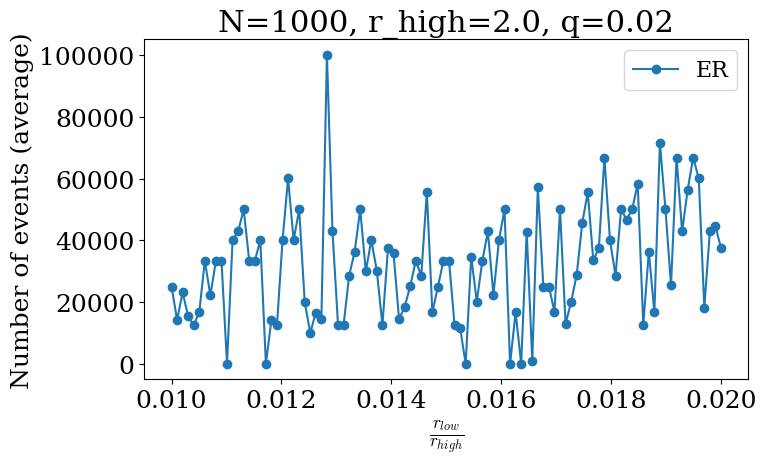

In [46]:
event_num_dict = {}

#---- 設定 ----
n_workers = cpu_count()
R = len(r_frac_values)

#---- 1) 各 worker の event_times をキャッシュ ----
worker_data = []
for wid in range(n_workers):
    path = os.path.join(data_dir, f"{wid:02d}_results.npz")
    with np.load(path, allow_pickle=True) as d:
        # d["event_times"] は shape=(R, repeats) の object 配列
        worker_data.append(d["event_times"])

#---- 2) 合計長さ＆有効サンプル数を r_frac_idx ごとに初期化 ----
total_lengths = np.zeros(R, dtype=float)
valid_counts  = np.zeros(R, dtype=int)

#---- 3) 各 worker のデータから集計 ----
for ev_times in worker_data:
    # 各要素の長さを一括取得 (shape=(A, R))
    lengths = np.vectorize(lambda arr: arr.shape[0])(ev_times)
    # 長さが 20 以上のものだけをカウント対象に
    mask = (lengths > 20)

    # r_frac_idx ごとに合計長さを足し込み
    total_lengths += (lengths * mask).sum(axis=1)
    # r_frac_idx ごとに有効サンプル数を足し込み
    valid_counts  += mask.sum(axis=1)

#---- 4) 平均を計算 ----
event_num_ave = total_lengths / valid_counts

event_num_dict["ER"] = event_num_ave


#---- 5) 描画 ----
fig, ax = plt.subplots(figsize=(8, 5))
for key, value in event_num_dict.items():
    ax.plot(r_frac_values, value, marker="o", label=key)
ax.set_title(f"N={N}, r_high={r_high}, q={q}")
ax.set_xlabel(r"$\frac{r_{low}}{r_{high}}$")
ax.set_ylabel("Number of events (average)")
ax.legend()
plt.tight_layout()
plt.show()


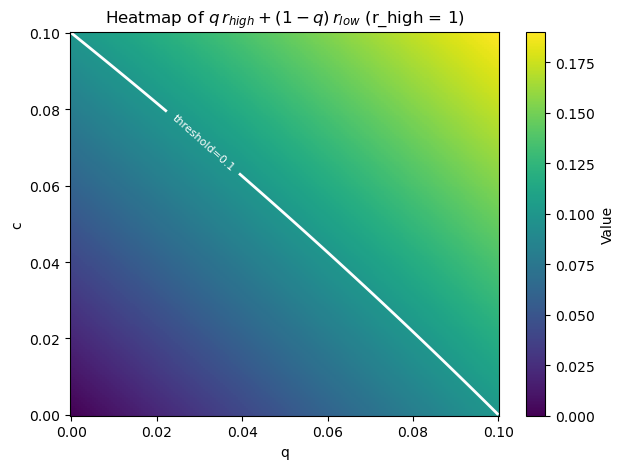

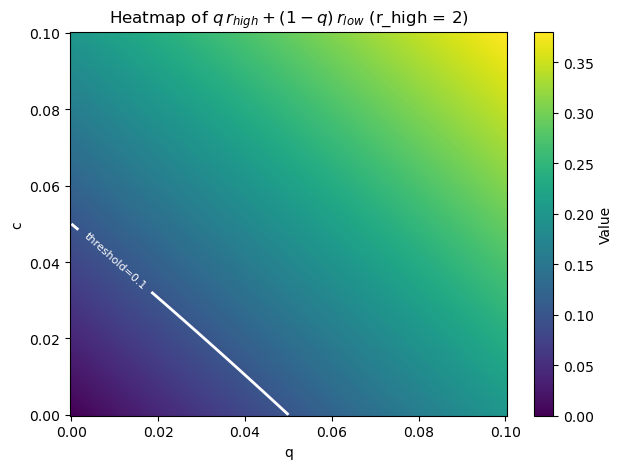

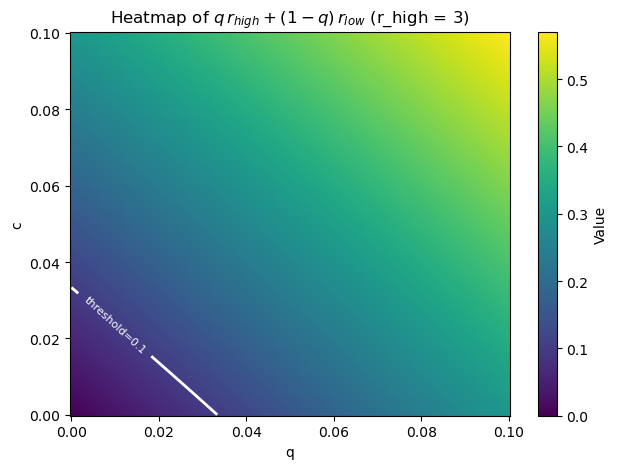

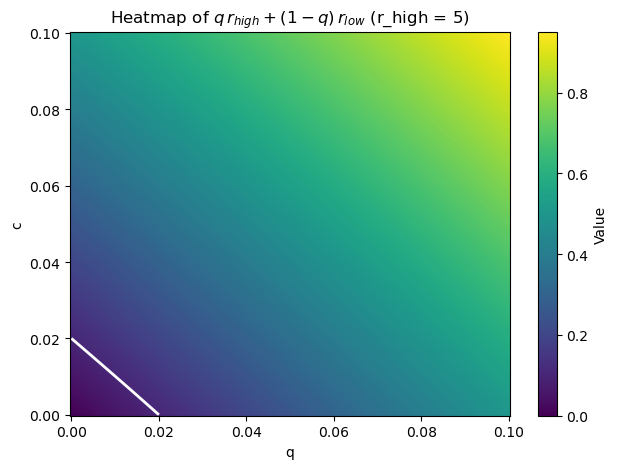

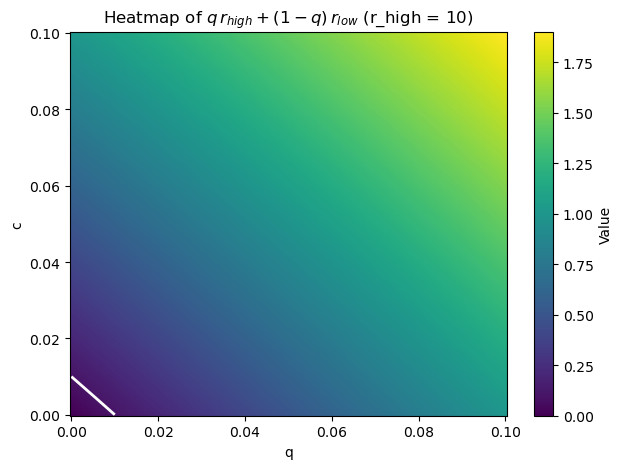

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
r_high_list = [1, 2, 3, 5, 10]
q = np.linspace(0, 0.1, 200)
c = np.linspace(0, 0.1, 200)
Q, C = np.meshgrid(q, c)

# Threshold
value_c = 0.1

# Generate a separate heatmap for each r_high value
for r_high in r_high_list:
    Z = r_high * (Q + (1 - Q) * C)
    
    plt.figure()
    # Plot the continuous heatmap
    pcm = plt.pcolormesh(Q, C, Z, shading='auto')
    plt.colorbar(pcm, label='Value')
    
    # Overlay contour at the threshold
    CS = plt.contour(Q, C, Z, levels=[value_c], colors='white', linewidths=2)
    plt.clabel(CS, fmt={value_c: f'threshold={value_c}'}, inline=True, fontsize=8, colors='white')
    
    plt.xlabel('q')
    plt.ylabel('c')
    plt.title(rf'Heatmap of $q\,r_{{high}} + (1-q)\,r_{{low}}$ (r_high = {r_high})')
    plt.tight_layout()
    plt.show()
